In [1]:
import pandas as pd
import seaborn as sns
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency


In [2]:
with open("../config.yaml", "r") as file:
    config = yaml.safe_load(file)

In [3]:
clients_test = pd.read_csv(config["output_data"]["file4"])
clients_test

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,test
1,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,test
2,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,test
3,388801,30.0,361.0,57.5,M,5.0,522498.72,1.0,4.0,test
4,8198645,15.0,189.0,54.5,F,2.0,382303.83,6.0,9.0,test
...,...,...,...,...,...,...,...,...,...,...
26956,501496,23.0,281.0,35.0,F,2.0,32529.34,0.0,3.0,test
26957,1780858,21.0,262.0,68.5,M,3.0,372100.59,6.0,9.0,test
26958,5826160,20.0,249.0,56.5,F,2.0,44837.16,2.0,5.0,test
26959,8739285,19.0,229.0,69.5,F,2.0,44994.24,1.0,4.0,test


In [4]:
clients_test.columns

Index(['client_id', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr',
       'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth', 'variation'],
      dtype='str')

In [5]:
# Filter test group by gender
female_clients_test = clients_test[clients_test['gendr'] == 'F']

# Quick check 

print(f"Test Female: {len(female_clients_test)}")


Test Female: 8716


In [6]:
male_clients_test = clients_test[clients_test['gendr'] == 'M']
male_clients_test
print(f"Test male: {len(male_clients_test)}")

Test male: 8977


In [7]:
unknown_clients_test = clients_test[clients_test['gendr'] == 'U']
unknown_clients_test
print(f"Test unknown: {len(unknown_clients_test)}")

Test unknown: 9266


Computing the difference between male and female clients does not make sence when the group of clients with unknown gender is the biggest group. We decided to discard the gender hypothesis and go with tenure years instead.

NEW Null Hypothesis:
The average client tenure(how long they've been with Vanguard) of users engaging with the new process is the same as the average client tenure of users engaging with the old process.

Alternative Hypothesis:
The average client tenure (how long they've been with Vanguard) of users engaging with the new process is different from the average client tenure of users engaging with the old process. If so what's the difference.

Make sure to consider:

the significance level,
p-value,
the statistical test prerequisites,
other relevant statistical measures in your analysis.

In [8]:
clients_control = pd.read_csv(config["output_data"]["file3"])
clients_control

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation
0,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,control
1,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,control
2,3727881,5.0,71.0,30.5,U,2.0,23915.60,0.0,3.0,control
3,272934,5.0,66.0,58.5,U,2.0,27021.42,2.0,5.0,control
4,285619,30.0,369.0,67.5,M,2.0,299388.72,3.0,6.0,control
...,...,...,...,...,...,...,...,...,...,...
23522,6662941,7.0,84.0,36.0,F,2.0,83101.84,4.0,7.0,control
23523,2787512,23.0,283.0,48.0,F,3.0,123618.60,1.0,4.0,control
23524,9932367,23.0,280.0,57.0,F,2.0,94466.55,6.0,9.0,control
23525,4079649,23.0,276.0,62.5,M,3.0,57575.28,4.0,7.0,control


In [9]:
tenure_test = clients_test
tenure_test

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,test
1,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,test
2,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,test
3,388801,30.0,361.0,57.5,M,5.0,522498.72,1.0,4.0,test
4,8198645,15.0,189.0,54.5,F,2.0,382303.83,6.0,9.0,test
...,...,...,...,...,...,...,...,...,...,...
26956,501496,23.0,281.0,35.0,F,2.0,32529.34,0.0,3.0,test
26957,1780858,21.0,262.0,68.5,M,3.0,372100.59,6.0,9.0,test
26958,5826160,20.0,249.0,56.5,F,2.0,44837.16,2.0,5.0,test
26959,8739285,19.0,229.0,69.5,F,2.0,44994.24,1.0,4.0,test


In [10]:
tenure_test.columns

Index(['client_id', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr',
       'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth', 'variation'],
      dtype='str')

In [11]:
clients_test['clnt_tenure_yr'].unique()

array([ 6.,  5., 16., 30., 15.,  4.,  3., 11.,  8., 12.,  7., 19., 18.,
       23., 21.,  9., 14., 27., 24., 28., 13., 20., 10., 29., 17., 22.,
       25., 26., 32., 33., 35.,  2., 38., 31., 34., 36., 51., 47., 37.,
       40., 55., 48., 43., 49., 39., 42., 50., 46., 44.])

In [12]:
clients_test['logons_6_mnth'].unique()

array([9., 6., 4., 8., 7., 5., 3.])

In [13]:
tenure_control = clients_control

In [14]:
# Check tenure in both groups
print("TEST GROUP:")
print(tenure_test['clnt_tenure_yr'].describe())

print("\nCONTROL GROUP:")
print(tenure_control['clnt_tenure_yr'].describe())

TEST GROUP:
count    26961.000000
mean        11.982901
std          6.844947
min          2.000000
25%          6.000000
50%         11.000000
75%         15.000000
max         55.000000
Name: clnt_tenure_yr, dtype: float64

CONTROL GROUP:
count    23527.000000
mean        12.087686
std          6.877531
min          2.000000
25%          6.000000
50%         11.000000
75%         16.000000
max         55.000000
Name: clnt_tenure_yr, dtype: float64


Independence is logically confirmed by asking:
Are these different people/entities?✅ Yes, different clients
Could one observation influence another?❌ No, clients are independent
Is the same person in both groups?❌ No, test and control are separate clients

In [15]:
# Normality test for both groups
stat_test, p_test = stats.normaltest(tenure_test['clnt_tenure_yr'])
stat_control, p_control = stats.normaltest(tenure_control['clnt_tenure_yr'])

print(f"Test group normality p-value: {p_test:.10f}")
print(f"Control group normality p-value: {p_control:.10f}")

Test group normality p-value: 0.0000000000
Control group normality p-value: 0.0000000000


For both groups p-value is 0 so not normally ditributed. This is common in bigger datasets. 
But we can use the Central Limit Theorem which says:

"With a large enough sample size (usually >30), the distribution of the mean behaves normally — regardless of the original distribution!"

Equal variances:          Unequal variances:
Test:    ████████         Test:    ██
Control: ████████         Control: ████████████████

In [16]:
# Levene's test for equal variances
stat, p_levene = stats.levene(tenure_test['clnt_tenure_yr'], tenure_control['clnt_tenure_yr'])

print(f"Levene's test p-value: {p_levene:.4f}")

Levene's test p-value: 0.3702


p-value = 0.3702 which is > 0.05 → variances are equal ✅
So our checklist is now:

✅ Independence — logically confirmed
✅ Normality — CLT saves us
✅ Equal variances — confirmed by Levene's test

let's run a T-test: "Are the averages of two groups significantly different, or is it just random chance?"
set the significance level: 0.05 normal 

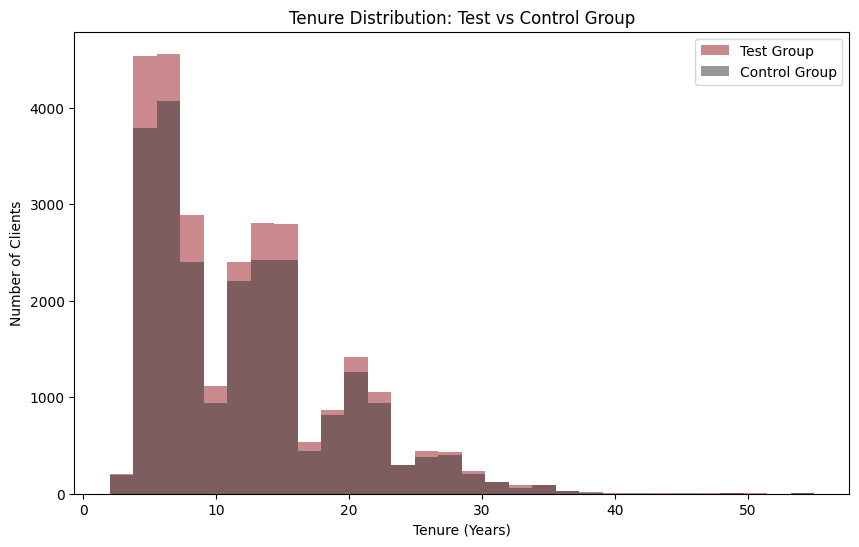

In [17]:
plt.figure(figsize=(10, 6))
plt.hist(tenure_test['clnt_tenure_yr'], bins=30, alpha=0.5, label='Test Group', color='#96151D')
plt.hist(tenure_control['clnt_tenure_yr'], bins=30, alpha=0.5, label='Control Group', color='#333333')
plt.xlabel('Tenure (Years)')
plt.ylabel('Number of Clients')
plt.title('Tenure Distribution: Test vs Control Group')
plt.legend()
plt.show()

In [18]:
# T-test with equal variances
stat, p_ttest = stats.ttest_ind(
    tenure_test['clnt_tenure_yr'], 
    tenure_control['clnt_tenure_yr'],
    equal_var=True
)

print(f"T-statistic: {stat:.4f}")
print(f"P-value: {p_ttest:.4f}")

T-statistic: -1.7121
P-value: 0.0869


P-value (0.0869) > α (0.05) → Fail to reject H₀
"The difference in average tenure between test and control groups is not statistically significant — it's likely just random chance!"

Follow up Hypothesis:
H₀: The completion rate of the new process is the same as the old process
H₁: The completion rate of the new process is different from the old process

In [19]:
df_web = pd.read_csv(config["output_data"]["file6"])
df_web

,client_id,visitor_id,visit_id,process_step,date_time
0,169,201385055_71273495308,749567106_99161211863_557568,start,2017-04-12 20:19:36
1,169,201385055_71273495308,749567106_99161211863_557568,step_1,2017-04-12 20:19:45
2,169,201385055_71273495308,749567106_99161211863_557568,step_2,2017-04-12 20:20:31
3,169,201385055_71273495308,749567106_99161211863_557568,step_3,2017-04-12 20:22:05
4,169,201385055_71273495308,749567106_99161211863_557568,confirm,2017-04-12 20:23:09
...,...,...,...,...,...
755400,9999875,738878760_1556639849,931268933_219402947_599432,step_1,2017-06-01 22:40:08
755401,9999875,738878760_1556639849,931268933_219402947_599432,step_1,2017-06-01 22:41:28
755402,9999875,738878760_1556639849,931268933_219402947_599432,step_2,2017-06-01 22:41:47
755403,9999875,738878760_1556639849,931268933_219402947_599432,step_3,2017-06-01 22:44:58


check for errors in the process
1. First check the overall data quality in df_web
2. Then split and compare errors between groups

In [20]:
# Get all client_ids that reached confirm
confirmed_clients = df_web[df_web['process_step'] == 'confirm']['client_id'].unique()

# For each confirmed client, check if they have all steps
steps = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

# Check which confirmed clients have all steps
complete_journeys = df_web[df_web['client_id'].isin(confirmed_clients)].groupby('client_id')['process_step'].apply(set)

# Check if all steps are present
complete_journeys = complete_journeys.apply(lambda x: all(step in x for step in steps))

print(f"Clients who confirmed WITH all steps: {complete_journeys.sum()}")
print(f"Clients who confirmed WITHOUT all steps: {(~complete_journeys).sum()}")

Clients who confirmed WITH all steps: 79733
Clients who confirmed WITHOUT all steps: 1412


There are 1,412 clients who somehow reached "confirm" without completing all steps — that's about 1.7% of confirmed clients.
These are likely data errors 🐛. A few possible explanations:

Technical glitches in the tracking system
Clients who skipped steps somehow
Data collection errors

But it could be more serious, noone should be able to reach confirm whitout for example logging in.

Are these errors evenly spread between test and control groups, or are there more errors in one group?

In [21]:
# Get the problematic client_ids
incomplete_confirmers = complete_journeys[~complete_journeys].index

# Check which group they belong to
# First what are the names of your test and control dataframes?
# And do they have a 'client_id' column?

test_errors = incomplete_confirmers.isin(tenure_test['client_id']).sum()
control_errors = incomplete_confirmers.isin(tenure_control['client_id']).sum()

print(f"Incomplete confirmers in TEST group: {test_errors}")
print(f"Incomplete confirmers in CONTROL group: {control_errors}")

Incomplete confirmers in TEST group: 349
Incomplete confirmers in CONTROL group: 228


Test group:
Incomplete confirmers: 349
Total clients: 26.961
Error rate: 1.29%

Control group:
Incomplete confirmers: 228
Total clients: 23.527
Error rate: 0.97%

The error rates are very similar (1.29% vs 0.97%) — both are tiny!
However there are 575 unaccounted errors (349 + 228 = 577, but total was 1,412) — meaning some incomplete confirmers don't belong to either group.

What to do with these errors?
I removed them from the analysis because:

- They represent bad/incomplete data
- The error rate is similar in both groups so removing them won't bias your results
- They could skew your completion rate calculations

Note: Alex went along and included the incomplete confirmers.
To see the difference I will exclude them from the process

In [22]:
# Remove incomplete confirmers from df_web
#not the ~ is a negation operator! so it flips it. it is looking for client_ids NOT in incomplete confirmers)
error_free_df_web = df_web[~df_web['client_id'].isin(incomplete_confirmers)]

print(f"Original df_web rows: {len(df_web)}")
print(f"Error_free_df_web rows: {len(error_free_df_web)}")

Original df_web rows: 755405
Error_free_df_web rows: 749101


In [23]:
# Remove incomplete confirmers from df_web
error_free_df_web = df_web[~df_web['client_id'].isin(incomplete_confirmers)]

# Only keep clients in test or control group
all_clients = pd.concat([tenure_test[['client_id']], tenure_control[['client_id']]])
error_free_df_web = error_free_df_web[error_free_df_web['client_id'].isin(all_clients['client_id'])]

print(f"Original df_web rows: {len(df_web)}")
print(f"Error_free_df_web rows: {len(error_free_df_web)}")

Original df_web rows: 755405
Error_free_df_web rows: 318706


Error_free_df_web rows: 749.101
Error free and part of test or control group : 318.706

This means a lot of web activity in df_web belongs to clients that are not in your test or control group at all.

In [24]:
#save web_df without errors and only test or control group
#error_free_df_web.to_csv('error_free_df_web.csv', index=False)

In [25]:
# Find clients who completed the process (reached 'confirm')
completed = error_free_df_web[error_free_df_web['process_step'] == 'confirm']['client_id'].unique()

# Check completion for test and control groups
test_completed = tenure_test['client_id'].isin(completed).sum()
test_not_completed = len(tenure_test) - test_completed

control_completed = tenure_control['client_id'].isin(completed).sum()
control_not_completed = len(tenure_control) - control_completed

# Build contingency table
contingency_table = pd.DataFrame({
    'Completed': [test_completed, control_completed],
    'Not Completed': [test_not_completed, control_not_completed]
}, index=['Test', 'Control'])

print(contingency_table)

         Completed  Not Completed
Test         18333           8628
Control      15201           8326


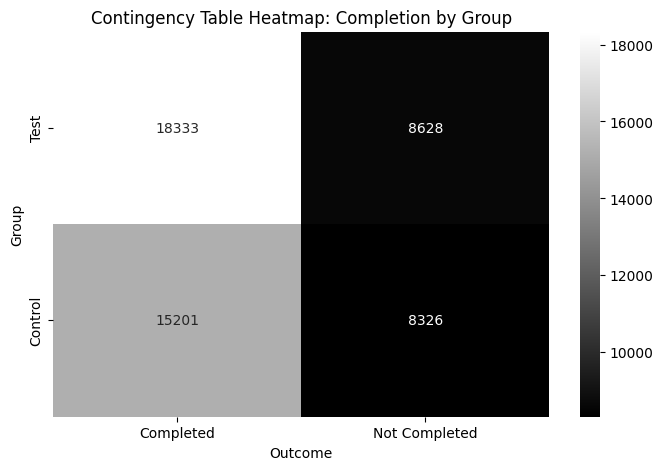

In [29]:
plt.figure(figsize=(8, 5))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='grey')
plt.title('Contingency Table Heatmap: Completion by Group')
plt.ylabel('Group')
plt.xlabel('Outcome')
plt.show()

In [30]:
test_percentage_completed = (18333 /26961)*100
control_percentage_completed = (15201 /23527)*100
print(test_percentage_completed)
print(control_percentage_completed)

67.99821965060643
64.61087261444298


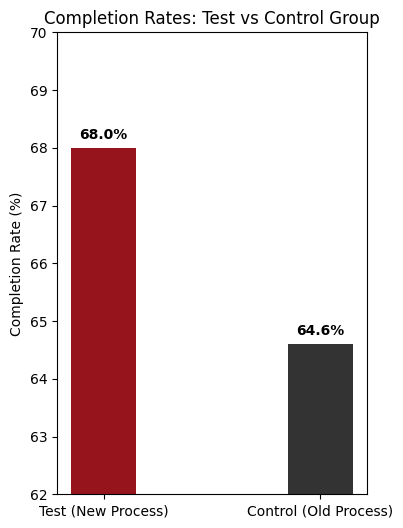

In [31]:
groups = ['Test (New Process)', 'Control (Old Process)']
completion_rates = [68.0, 64.6]

plt.figure(figsize=(4, 6))
bars = plt.bar(groups, completion_rates, color=['#96151D', '#333333'], width=0.3)
plt.ylabel('Completion Rate (%)')
plt.title('Completion Rates: Test vs Control Group')
plt.ylim(62, 70)  # zoom in to make difference visible

# Add percentage labels on top of bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.1, 
             f'{bar.get_height()}%', 
             ha='center', va='bottom', fontweight='bold')

plt.show()

In [32]:
# Run Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic: 64.4810
P-value: 0.0000
Degrees of freedom: 1


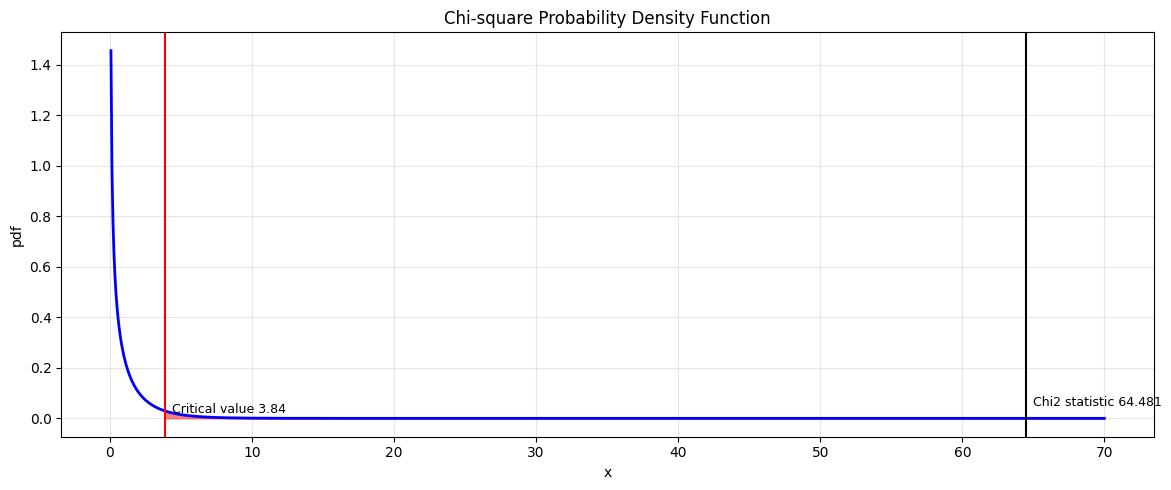

In [33]:
# Parameters
chi2_stat = 64.4810
df = 1
alpha = 0.05

# Critical value (one-tailed for chi-square)
critical_value = stats.chi2.ppf(1 - alpha, df)

# X axis
x = np.linspace(0, 70, 1000)
y = stats.chi2.pdf(x, df)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(x, y, 'b-', linewidth=2)

# Rejection region
plt.fill_between(x, y, where=(x >= critical_value), color='red', alpha=0.5)

# Critical value line
plt.axvline(x=critical_value, color='red', linewidth=1.5)
plt.axvline(x=chi2_stat, color='black', linewidth=1.5)

# Labels
plt.text(critical_value + 0.5, 0.02, f'Critical value {critical_value:.2f}', fontsize=9)
plt.text(chi2_stat + 0.5, 0.05, f'Chi2 statistic {chi2_stat}', fontsize=9)

plt.title('Chi-square Probability Density Function')
plt.xlabel('x')
plt.ylabel('pdf')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

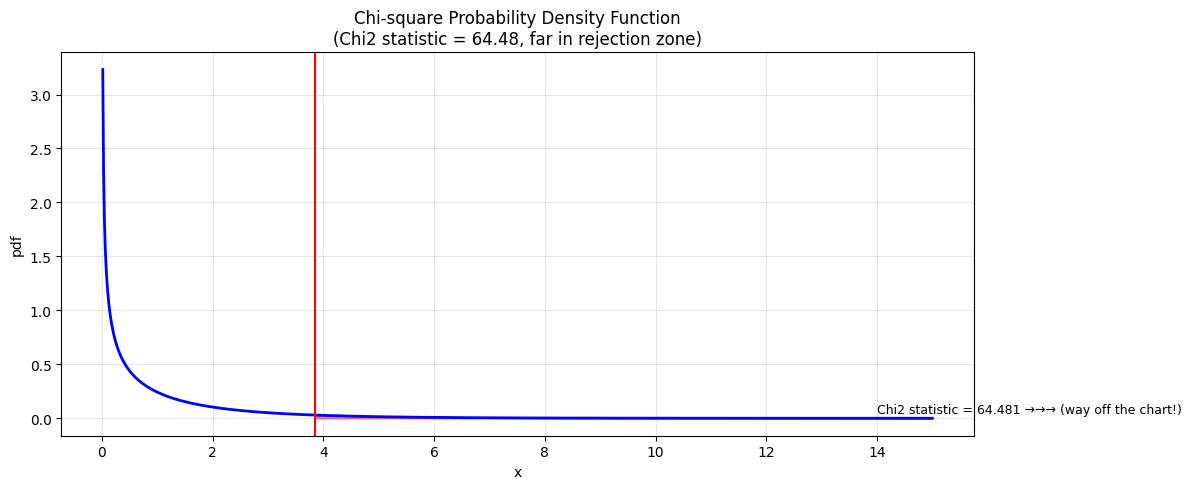

In [34]:
# Zoom in to make it more readable
x = np.linspace(0, 15, 1000)  # zoom in instead of going to 70
y = stats.chi2.pdf(x, df)

plt.figure(figsize=(12, 5))
plt.plot(x, y, 'b-', linewidth=2)

# Rejection region
plt.fill_between(x, y, where=(x >= critical_value), color='red', alpha=0.5)

# Lines
plt.axvline(x=critical_value, color='red', linewidth=1.5)

# Arrow pointing to chi2 statistic off the chart
plt.annotate(f'Chi2 statistic = {chi2_stat} →→→ (way off the chart!)', 
             xy=(14, 0.05), fontsize=9, color='black')

plt.title('Chi-square Probability Density Function\n(Chi2 statistic = 64.48, far in rejection zone)')
plt.xlabel('x')
plt.ylabel('pdf')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

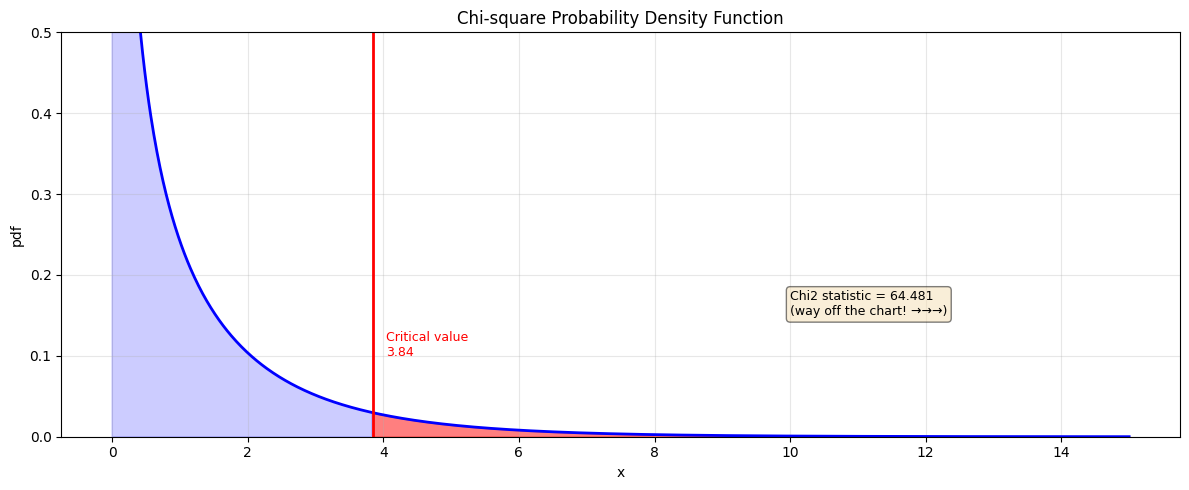

In [35]:
x = np.linspace(0.001, 15, 1000)
y = stats.chi2.pdf(x, df)

plt.figure(figsize=(12, 5))
plt.plot(x, y, 'b-', linewidth=2)

# Rejection region - fill between critical value and end of chart
plt.fill_between(x, y, where=(x >= critical_value), color='red', alpha=0.5)

# Non rejection region
plt.fill_between(x, y, where=(x < critical_value), color='blue', alpha=0.2)

# Critical value line
plt.axvline(x=critical_value, color='red', linewidth=2)

# Labels
plt.text(critical_value + 0.2, 0.1, f'Critical value\n{critical_value:.2f}', 
         fontsize=9, color='red')
plt.text(10, 0.15, f'Chi2 statistic = {chi2_stat}\n(way off the chart! →→→)', 
         fontsize=9, color='black',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.title('Chi-square Probability Density Function')
plt.xlabel('x')
plt.ylabel('pdf')
plt.ylim(0, 0.5)  # limit y axis so curve looks better
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The Control group has a 64.6% completion rate
The Test group has a 68% completion rate
difference is +3.4%

Chi-square (64.48) → very far from 0 → the difference between groups is very large
P-value (0.0000) → basically 0% chance this difference is random
Degrees of freedom (1) → we have 2 groups and 2 outcomes (completed/not) → always 1 in a 2x2 table

"The new process significantly improves completion rates — this is NOT random chance!"

In [36]:
# Create tenure buckets in both groups
bins = [0, 5, 15, 30, 55]
labels = ['New (0-5yr)', 'Mid (6-15yr)', 'Loyal (16-30yr)', 'Veteran (30+yr)']

tenure_test['tenure_group'] = pd.cut(tenure_test['clnt_tenure_yr'], bins=bins, labels=labels)
tenure_control['tenure_group'] = pd.cut(tenure_control['clnt_tenure_yr'], bins=bins, labels=labels)

# Add completed column to both groups
tenure_test['completed'] = tenure_test['client_id'].isin(completed).astype(int)
tenure_control['completed'] = tenure_control['client_id'].isin(completed).astype(int)

# Calculate completion rate per tenure group
test_rates = tenure_test.groupby('tenure_group')['completed'].mean() * 100
control_rates = tenure_control.groupby('tenure_group')['completed'].mean() * 100

print("TEST completion rates by tenure group:")
print(test_rates)
print("\nCONTROL completion rates by tenure group:")
print(control_rates)

TEST completion rates by tenure group:
tenure_group
New (0-5yr)        69.407548
Mid (6-15yr)       68.170700
Loyal (16-30yr)    66.687817
Veteran (30+yr)    65.079365
Name: completed, dtype: float64

CONTROL completion rates by tenure group:
tenure_group
New (0-5yr)        65.429002
Mid (6-15yr)       64.705882
Loyal (16-30yr)    63.678161
Veteran (30+yr)    66.765579
Name: completed, dtype: float64


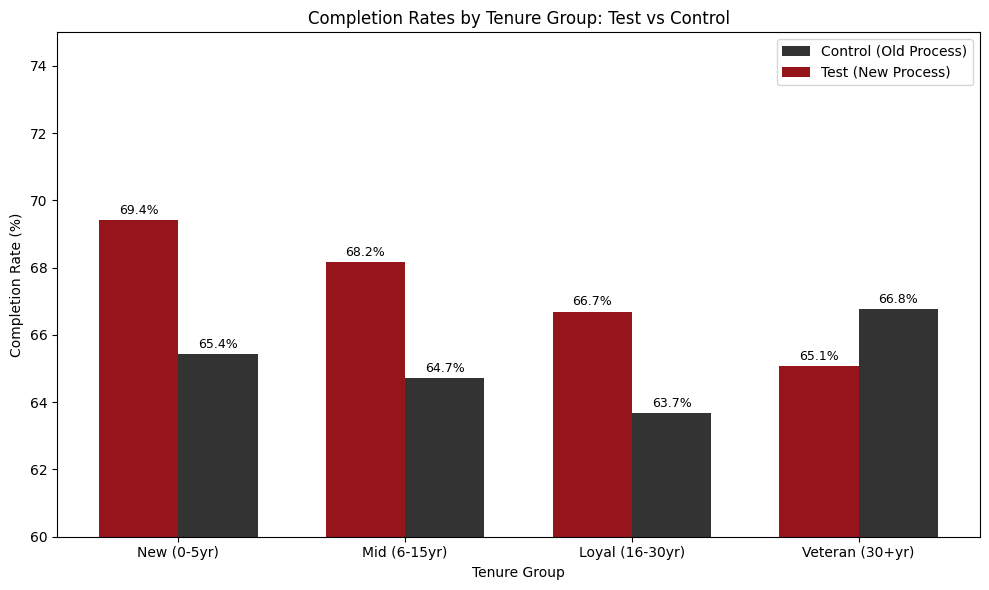

In [39]:
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x + width/2, control_rates, width, label='Control (Old Process)', color='#333333')
bars2 = ax.bar(x - width/2, test_rates, width, label='Test (New Process)', color='#96151D')


ax.set_xlabel('Tenure Group')
ax.set_ylabel('Completion Rate (%)')
ax.set_title('Completion Rates by Tenure Group: Test vs Control')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(60, 75)

# Add percentage labels on top of bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
""" Create 5-year tenure buckets
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55]
labels = ['0-5', '6-10', '11-15', '16-20', '21-25', '26-30', '31-35', '36-40', '41-45', '46-50', '51-55']

tenure_test['tenure_group'] = pd.cut(tenure_test['clnt_tenure_yr'], bins=bins, labels=labels)
tenure_control['tenure_group'] = pd.cut(tenure_control['clnt_tenure_yr'], bins=bins, labels=labels)

# Calculate completion rate per tenure group
test_rates = tenure_test.groupby('tenure_group')['completed'].mean() * 100
control_rates = tenure_control.groupby('tenure_group')['completed'].mean() * 100

# Plot
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 8))  # wider figure for more groups
bars1 = ax.bar(x - width/2, test_rates, width, label='Test (New Process)', color='green')
bars2 = ax.bar(x + width/2, control_rates, width, label='Control (Old Process)', color='purple')

ax.set_xlabel('Tenure Group (Years)')
ax.set_ylabel('Completion Rate (%)')
ax.set_title('Completion Rates by Tenure Group: Test vs Control')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)  # rotate labels so they don't overlap
ax.legend()
ax.set_ylim(50, 80)

plt.tight_layout()
plt.show()"""

" Create 5-year tenure buckets\nbins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55]\nlabels = ['0-5', '6-10', '11-15', '16-20', '21-25', '26-30', '31-35', '36-40', '41-45', '46-50', '51-55']\n\ntenure_test['tenure_group'] = pd.cut(tenure_test['clnt_tenure_yr'], bins=bins, labels=labels)\ntenure_control['tenure_group'] = pd.cut(tenure_control['clnt_tenure_yr'], bins=bins, labels=labels)\n\n# Calculate completion rate per tenure group\ntest_rates = tenure_test.groupby('tenure_group')['completed'].mean() * 100\ncontrol_rates = tenure_control.groupby('tenure_group')['completed'].mean() * 100\n\n# Plot\nx = np.arange(len(labels))\nwidth = 0.35\n\nfig, ax = plt.subplots(figsize=(14, 8))  # wider figure for more groups\nbars1 = ax.bar(x - width/2, test_rates, width, label='Test (New Process)', color='green')\nbars2 = ax.bar(x + width/2, control_rates, width, label='Control (Old Process)', color='purple')\n\nax.set_xlabel('Tenure Group (Years)')\nax.set_ylabel('Completion Rate (%)')\nax.set_

This plot is not reliable because the older tenure groups consist of very few people.
Let's check how many people are in which tenure group and make better combinations.

In [40]:
print("TEST clients per tenure group:")
print(tenure_test['tenure_group'].value_counts().sort_index())

print("\nCONTROL clients per tenure group:")
print(tenure_control['tenure_group'].value_counts().sort_index())

TEST clients per tenure group:
tenure_group
New (0-5yr)         4743
Mid (6-15yr)       15536
Loyal (16-30yr)     6304
Veteran (30+yr)      378
Name: count, dtype: int64

CONTROL clients per tenure group:
tenure_group
New (0-5yr)         3986
Mid (6-15yr)       13549
Loyal (16-30yr)     5655
Veteran (30+yr)      337
Name: count, dtype: int64


In [41]:
# Recreate bins with 31+ as last group
bins = [0, 5, 10, 15, 20, 25, 30, 55]
labels = ['0-5', '6-10', '11-15', '16-20', '21-25', '26-30', '31+']

tenure_test['tenure_group'] = pd.cut(tenure_test['clnt_tenure_yr'], bins=bins, labels=labels)
tenure_control['tenure_group'] = pd.cut(tenure_control['clnt_tenure_yr'], bins=bins, labels=labels)

test_rates = tenure_test.groupby('tenure_group')['completed'].mean() * 100
control_rates = tenure_control.groupby('tenure_group')['completed'].mean() * 100

print("TEST completion rates:")
print(test_rates)
print("\nCONTROL completion rates:")
print(control_rates)

TEST completion rates:
tenure_group
0-5      69.407548
6-10     69.230769
11-15    66.867556
16-20    66.811207
21-25    67.957895
26-30    63.050483
31+      65.079365
Name: completed, dtype: float64

CONTROL completion rates:
tenure_group
0-5      65.429002
6-10     65.298961
11-15    63.990228
16-20    63.384956
21-25    64.488636
26-30    62.575211
31+      66.765579
Name: completed, dtype: float64


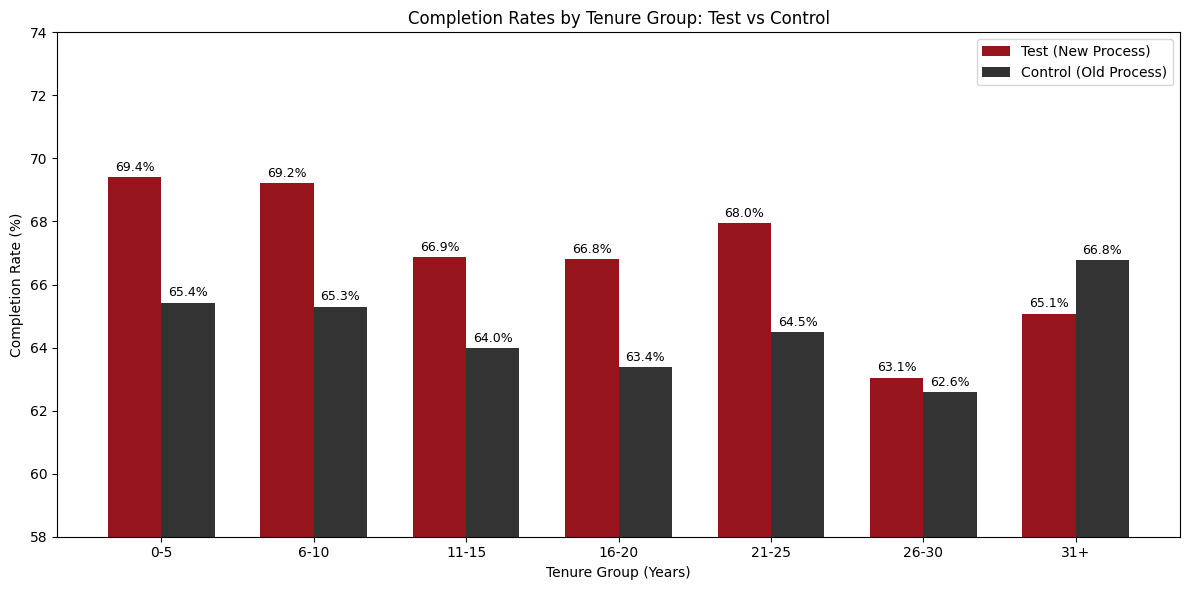

In [43]:
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars2 = ax.bar(x - width/2, test_rates, width, label='Test (New Process)', color='#96151D')
bars1 = ax.bar(x + width/2, control_rates, width, label='Control (Old Process)', color='#333333')

ax.set_xlabel('Tenure Group (Years)')
ax.set_ylabel('Completion Rate (%)')
ax.set_title('Completion Rates by Tenure Group: Test vs Control')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(58, 74)

# Add percentage labels on top of bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Two key conclusions:

- The new process works better for most clients — especially newer clients (0-10 years) where the difference is biggest (~4%)
- Long tenured clients (31+) actually prefer the old process — these are Vanguard's most loyal clients and they seem to struggle with the new process!

Let's check how many clients aborted the process after which step

In [44]:
# Define the steps in order
steps = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

# Get the last step each client reached
last_step = error_free_df_web.groupby('client_id')['process_step'].apply(
    lambda x: x.iloc[x.map(steps.index).argmax()]
)

# Count how many clients stopped at each step (excluding confirm)
dropped_at = last_step[last_step != 'confirm'].value_counts()

print("Clients who abandoned at each step:")
print(f"Abandoned after start:  {dropped_at.get('start', 0)}")
print(f"Abandoned after step 1: {dropped_at.get('step_1', 0)}")
print(f"Abandoned after step 2: {dropped_at.get('step_2', 0)}")
print(f"Abandoned after step 3: {dropped_at.get('step_3', 0)}")
print(f"\nTotal abandoned: {dropped_at.sum()}")
print(f"Total completed: {(last_step == 'confirm').sum()}")

Clients who abandoned at each step:
Abandoned after start:  5739
Abandoned after step 1: 3434
Abandoned after step 2: 2675
Abandoned after step 3: 4529

Total abandoned: 16377
Total completed: 33534


In [45]:
# Define the steps in order
steps = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

for group in ['test', 'control']:
    # Get clients for this group
    if group == 'test':
        group_clients = tenure_test['client_id']
    else:
        group_clients = tenure_control['client_id']
    
    # Filter web data for this group
    group_df = error_free_df_web[error_free_df_web['client_id'].isin(group_clients)]
    
    # Get last step each client reached
    last_step = group_df.groupby('client_id')['process_step'].apply(
        lambda x: x.iloc[x.map(steps.index).argmax()]
    )
    
    # Count abandonments
    dropped_at = last_step[last_step != 'confirm'].value_counts()
    total_clients = len(group_clients)
    
    print(f"\n{'='*30}")
    print(f"{group.upper()} GROUP ({total_clients} clients):")
    print(f"{'='*30}")
    print(f"Abandoned after start:  {dropped_at.get('start', 0)}")
    print(f"Abandoned after step 1: {dropped_at.get('step_1', 0)}")
    print(f"Abandoned after step 2: {dropped_at.get('step_2', 0)}")
    print(f"Abandoned after step 3: {dropped_at.get('step_3', 0)}")
    print(f"Total abandoned: {dropped_at.sum()}")
    print(f"Total completed: {(last_step == 'confirm').sum()}")


TEST GROUP (26961 clients):
Abandoned after start:  2454
Abandoned after step 1: 1979
Abandoned after step 2: 1410
Abandoned after step 3: 2436
Total abandoned: 8279
Total completed: 18333

CONTROL GROUP (23527 clients):
Abandoned after start:  3285
Abandoned after step 1: 1455
Abandoned after step 2: 1265
Abandoned after step 3: 2093
Total abandoned: 8098
Total completed: 15201


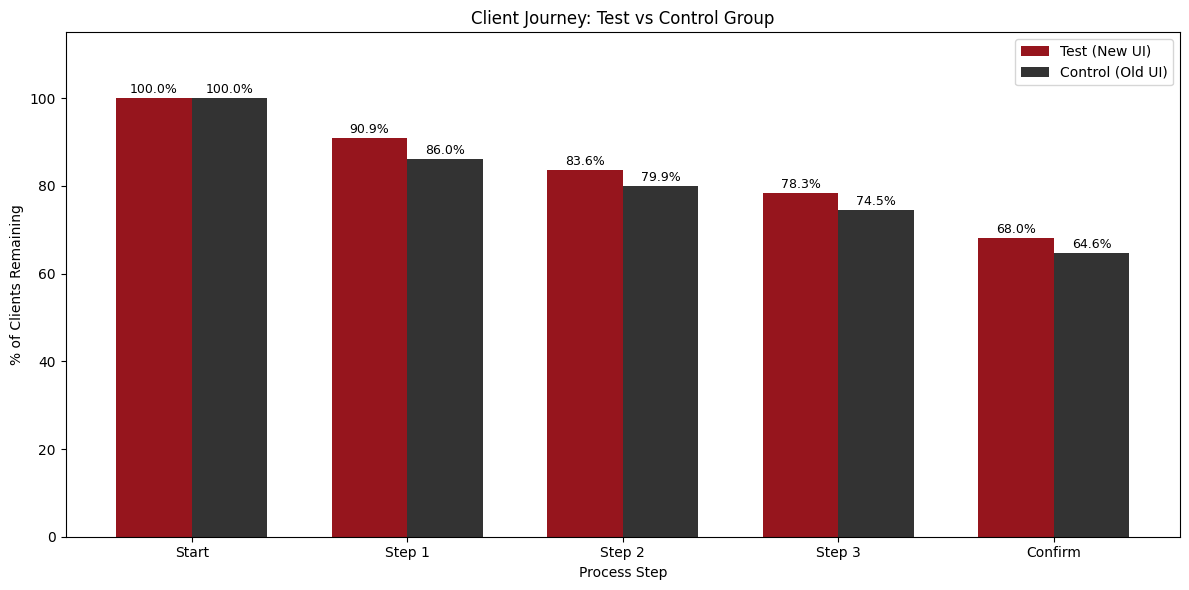

In [46]:
# Data
steps_labels = ['Start', 'Step 1', 'Step 2', 'Step 3', 'Confirm']

test_counts = [26961, 26961-2454, 26961-2454-1979, 26961-2454-1979-1410, 18333]
control_counts = [23527, 23527-3285, 23527-3285-1455, 23527-3285-1455-1265, 15201]

# Convert to percentages
test_pct = [x/26961*100 for x in test_counts]
control_pct = [x/23527*100 for x in control_counts]

# Plot
x = np.arange(len(steps_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, test_pct, width, label='Test (New UI)', color='#96151D')
bars2 = ax.bar(x + width/2, control_pct, width, label='Control (Old UI)', color='#333333')

# Add percentage labels on top of bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Process Step')
ax.set_ylabel('% of Clients Remaining')
ax.set_title('Client Journey: Test vs Control Group')
ax.set_xticks(x)
ax.set_xticklabels(steps_labels)
ax.set_ylim(0, 115)
ax.legend()

plt.tight_layout()
plt.show()

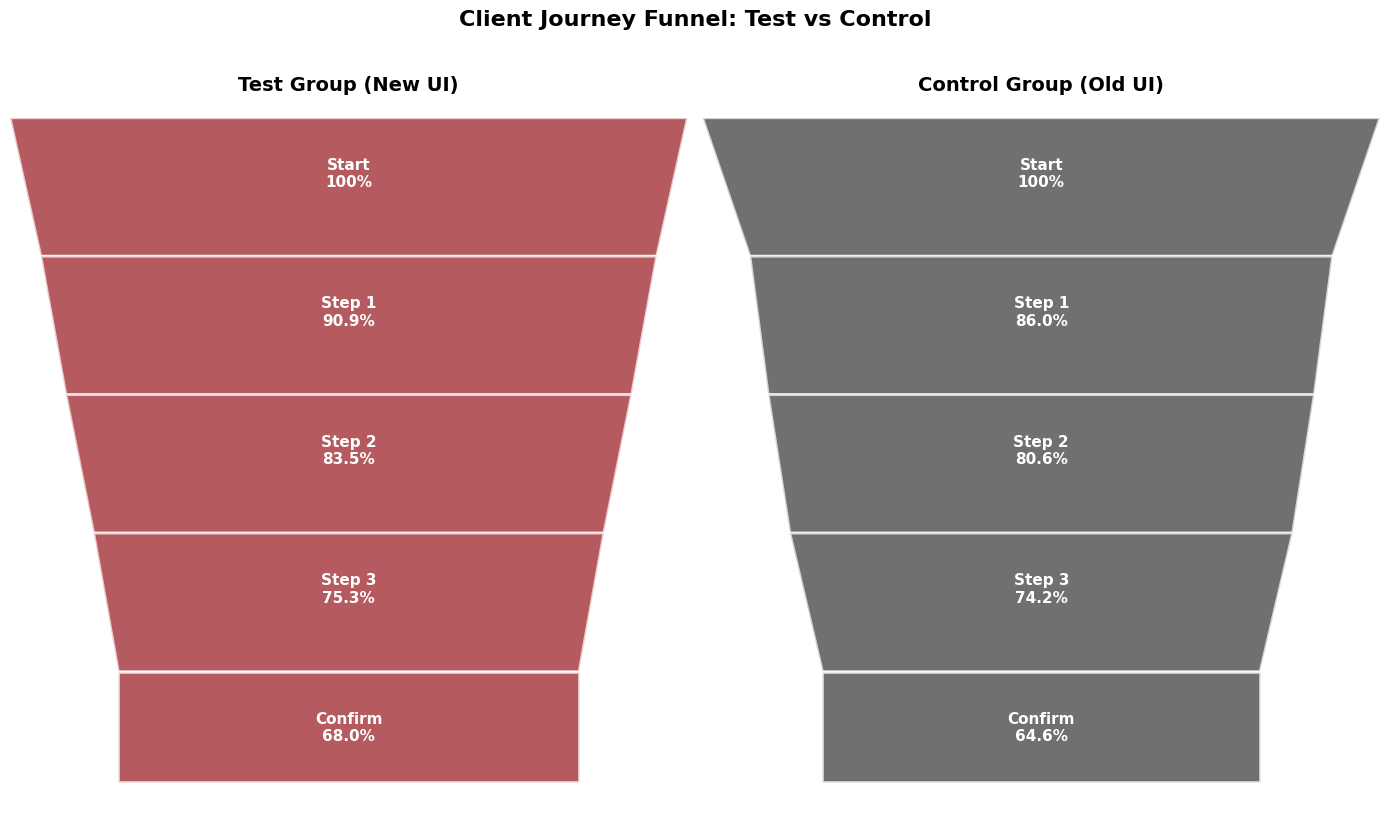

In [48]:
# Data as percentages
steps_labels = ['Start', 'Step 1', 'Step 2', 'Step 3', 'Confirm']
test_pct = [100, 90.9, 83.5, 75.3, 68.0]
control_pct = [100, 86.0, 80.6, 74.2, 64.6]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

def draw_funnel(ax, data, labels, color, title):
    max_width = 0.8
    for i, (pct, label) in enumerate(zip(data, labels)):
        width = max_width * pct / 100
        left = (max_width - width) / 2
        
        # Draw trapezoid shape
        if i < len(data) - 1:
            next_width = max_width * data[i+1] / 100
            next_left = (max_width - next_width) / 2
            coords = [[left, -i], [left+width, -i], 
                      [next_left+next_width, -i-1], [next_left, -i-1]]
        else:
            coords = [[left, -i], [left+width, -i],
                      [left+width, -i-0.8], [left, -i-0.8]]
        
        polygon = plt.Polygon(coords, closed=True, 
                             facecolor=color, alpha=0.7,
                             edgecolor='white', linewidth=2)
        ax.add_patch(polygon)
        
        # Add labels
        ax.text(0.4, -i-0.4, f'{label}\n{pct}%', 
                ha='center', va='center', 
                fontsize=11, fontweight='bold', color='white')
    
    ax.set_xlim(0, max_width)
    ax.set_ylim(-len(data), 0)
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)

draw_funnel(ax1, test_pct, steps_labels, '#96151D', 'Test Group (New UI)')
draw_funnel(ax2, control_pct, steps_labels, '#333333', 'Control Group (Old UI)')

plt.suptitle('Client Journey Funnel: Test vs Control', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

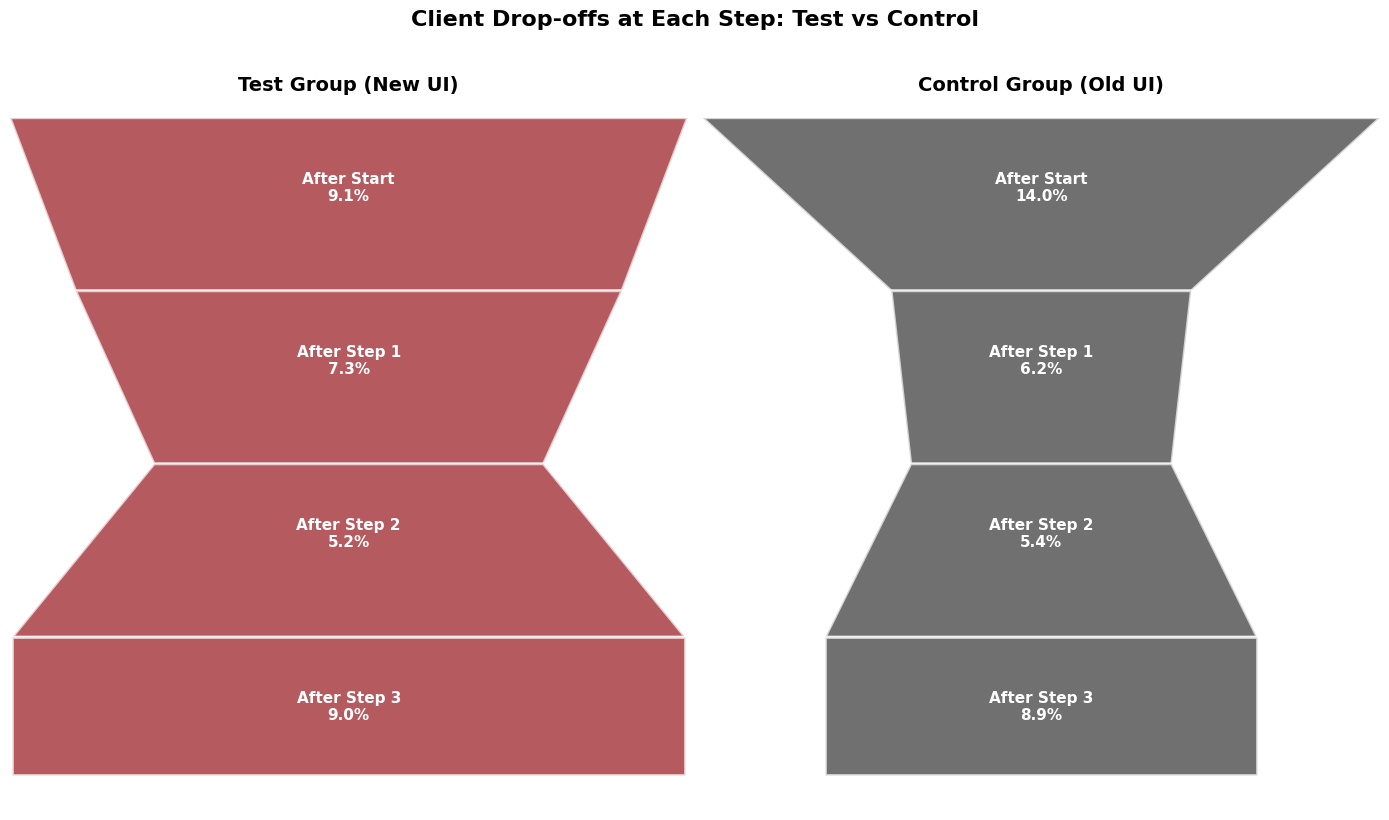

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

# Drop-off percentages
steps_labels = ['After Start', 'After Step 1', 'After Step 2', 'After Step 3']

test_dropoff = [2454/26961*100, 1979/26961*100, 1410/26961*100, 2436/26961*100]
control_dropoff = [3285/23527*100, 1455/23527*100, 1265/23527*100, 2093/23527*100]

def draw_reverse_funnel(ax, data, labels, color, title):
    max_width = 0.8
    for i, (pct, label) in enumerate(zip(data, labels)):
        width = max_width * pct / max(data)  # scale to biggest drop-off
        left = (max_width - width) / 2
        
        if i < len(data) - 1:
            next_width = max_width * data[i+1] / max(data)
            next_left = (max_width - next_width) / 2
            coords = [[left, -i], [left+width, -i],
                      [next_left+next_width, -i-1], [next_left, -i-1]]
        else:
            coords = [[left, -i], [left+width, -i],
                      [left+width, -i-0.8], [left, -i-0.8]]
        
        polygon = plt.Polygon(coords, closed=True,
                             facecolor=color, alpha=0.7,
                             edgecolor='white', linewidth=2)
        ax.add_patch(polygon)
        
        ax.text(0.4, -i-0.4, f'{label}\n{pct:.1f}%',
                ha='center', va='center',
                fontsize=11, fontweight='bold', color='white')
    
    ax.set_xlim(0, max_width)
    ax.set_ylim(-len(data), 0)
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)

draw_reverse_funnel(ax1, test_dropoff, steps_labels, '#96151D', 'Test Group (New UI)')
draw_reverse_funnel(ax2, control_dropoff, steps_labels, '#333333', 'Control Group (Old UI)')

plt.suptitle('Client Drop-offs at Each Step: Test vs Control',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

What each drop-off could mean:
Drop-off point:         What might have happened:
After Start             Client saw the new process and thought "this looks complicated" or "I don't have time for this"
After Step 1            Client started filling in details but got stuck or didn't have the information ready
After Step 2            Client entered recipient details but found an error or ran out of time
After Step 3            Client completed everything but hesitated at the final confirmation!

The Step 3 drop-off is actually the most frustrating one.
They did ALL the work and then didn't confirm!
This could mean:

The confirmation page is confusing or intimidating
Clients are not sure if the details are correct
The wording of the confirmation might be intimidating


In [50]:
# Find clients who have process steps but NO 'start'
clients_with_start = error_free_df_web[error_free_df_web['process_step'] == 'start']['client_id'].unique()
all_clients_in_web = error_free_df_web['client_id'].unique()

# Clients in web data but without a start step
clients_without_start = set(all_clients_in_web) - set(clients_with_start)

print(f"Total clients in web data: {len(all_clients_in_web)}")
print(f"Clients WITH start: {len(clients_with_start)}")
print(f"Clients WITHOUT start: {len(clients_without_start)}")

# What steps did these clients reach?
no_start_df = error_free_df_web[error_free_df_web['client_id'].isin(clients_without_start)]
print("\nSteps reached by clients without start:")
print(no_start_df['process_step'].value_counts())

Total clients in web data: 49911
Clients WITH start: 49878
Clients WITHOUT start: 33

Steps reached by clients without start:
process_step
step_1    43
step_2    37
step_3    20
Name: count, dtype: int64


In [51]:
# Check per group
for group in ['test', 'control']:
    if group == 'test':
        group_clients = tenure_test['client_id']
    else:
        group_clients = tenure_control['client_id']
    
    # Filter web data for this group
    group_df = error_free_df_web[error_free_df_web['client_id'].isin(group_clients)]
    
    # Find clients without start
    clients_with_start = group_df[group_df['process_step'] == 'start']['client_id'].unique()
    all_clients = group_df['client_id'].unique()
    clients_without_start = set(all_clients) - set(clients_with_start)
    
    print(f"\n{'='*30}")
    print(f"{group.upper()} GROUP:")
    print(f"{'='*30}")
    print(f"Total clients in web data: {len(all_clients)}")
    print(f"Clients WITH start: {len(clients_with_start)}")
    print(f"Clients WITHOUT start: {len(clients_without_start)}")
    
    # Steps reached by clients without start
    no_start_df = group_df[group_df['client_id'].isin(clients_without_start)]
    if len(no_start_df) > 0:
        print("\nSteps reached by clients without start:")
        print(no_start_df['process_step'].value_counts())


TEST GROUP:
Total clients in web data: 26612
Clients WITH start: 26598
Clients WITHOUT start: 14

Steps reached by clients without start:
process_step
step_1    16
step_2    12
step_3     5
Name: count, dtype: int64

CONTROL GROUP:
Total clients in web data: 23299
Clients WITH start: 23280
Clients WITHOUT start: 19

Steps reached by clients without start:
process_step
step_1    27
step_2    25
step_3    15
Name: count, dtype: int64


In [ ]:
#save cleaned data file
#no_start_df.to_csv('no_start_df.csv', index=False)

In [ ]:
""" Create a dataframe with your results for Tableau
import pandas as pd

data = {
    'Tenure Group': ['0-5', '6-10', '11-15', '16-20', '21-25', '26-30', '31+'],
    'Test Rate': [69.4, 69.2, 66.9, 66.8, 68.0, 63.1, 65.1],
    'Control Rate': [65.4, 65.3, 64.0, 63.4, 64.5, 62.6, 66.8]
}

df_tenure = pd.DataFrame(data)
df_tenure.to_csv('tenure_completion_rates.csv', index=False)"""

" Create a dataframe with your results for Tableau\nimport pandas as pd\n\ndata = {\n    'Tenure Group': ['0-5', '6-10', '11-15', '16-20', '21-25', '26-30', '31+'],\n    'Test Rate': [69.4, 69.2, 66.9, 66.8, 68.0, 63.1, 65.1],\n    'Control Rate': [65.4, 65.3, 64.0, 63.4, 64.5, 62.6, 66.8]\n}\n\ndf_tenure = pd.DataFrame(data)\ndf_tenure.to_csv('tenure_completion_rates.csv', index=False)"

In [ ]:
"""Convert to long format for Tableau
df_tenure_long = df_tenure.melt(
    id_vars=['Tenure Group'],
    value_vars=['Test Rate', 'Control Rate'],
    var_name='Group',
    value_name='Completion Rate'
)

# Clean up the Group column
df_tenure_long['Group'] = df_tenure_long['Group'].str.replace(' Rate', '')

print(df_tenure_long)
df_tenure_long.to_csv('tenure_completion_rates_long.csv', index=False)"""

"Convert to long format for Tableau\ndf_tenure_long = df_tenure.melt(\n    id_vars=['Tenure Group'],\n    value_vars=['Test Rate', 'Control Rate'],\n    var_name='Group',\n    value_name='Completion Rate'\n)\n\n# Clean up the Group column\ndf_tenure_long['Group'] = df_tenure_long['Group'].str.replace(' Rate', '')\n\nprint(df_tenure_long)\ndf_tenure_long.to_csv('tenure_completion_rates_long.csv', index=False)"

To make sure we are working with the same data in our presentation, below the same graphs but with the incomplete confirmers included


In [52]:
steps = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

for group in ['test', 'control']:
    if group == 'test':
        base_clients = tenure_test['client_id']
        group_incomplete = incomplete_confirmers[incomplete_confirmers.isin(tenure_test['client_id'])]
    else:
        base_clients = tenure_control['client_id']
        group_incomplete = incomplete_confirmers[incomplete_confirmers.isin(tenure_control['client_id'])]

    # ✅ Include incomplete confirmers
    all_group_clients = pd.Index(base_clients.tolist() + group_incomplete.tolist()).unique()

    group_df = df_web[df_web['client_id'].isin(all_group_clients)]

    last_step = group_df.groupby('client_id')['process_step'].apply(
        lambda x: x.iloc[x.map(steps.index).argmax()]
    )

    dropped_at = last_step[last_step != 'confirm'].value_counts()
    total_clients = len(all_group_clients)

    print(f"\n{'='*30}")
    print(f"{group.upper()} GROUP ({total_clients} clients):")
    print(f"{'='*30}")
    print(f"Abandoned after start:  {dropped_at.get('start', 0)}")
    print(f"Abandoned after step 1: {dropped_at.get('step_1', 0)}")
    print(f"Abandoned after step 2: {dropped_at.get('step_2', 0)}")
    print(f"Abandoned after step 3: {dropped_at.get('step_3', 0)}")
    print(f"Total abandoned: {dropped_at.sum()}")
    print(f"Total completed: {(last_step == 'confirm').sum()}")


TEST GROUP (26961 clients):
Abandoned after start:  2454
Abandoned after step 1: 1979
Abandoned after step 2: 1410
Abandoned after step 3: 2436
Total abandoned: 8279
Total completed: 18682

CONTROL GROUP (23527 clients):
Abandoned after start:  3285
Abandoned after step 1: 1455
Abandoned after step 2: 1265
Abandoned after step 3: 2093
Total abandoned: 8098
Total completed: 15429


Checking a sample of errors that occur during the process:

In [53]:
# Look at a sample of incomplete confirmers' steps
sample = incomplete_confirmers[:5]
df_web[df_web['client_id'].isin(sample)][['client_id', 'process_step']].sort_values('client_id')

,client_id,process_step
198,1702,confirm
199,1702,confirm
200,1702,confirm
681,8030,start
682,8030,start
683,8030,step_1
684,8030,step_2
685,8030,confirm
2037,26196,confirm
2038,26196,start


In [54]:
steps = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

for group in ['test', 'control']:
    if group == 'test':
        group_clients = tenure_test['client_id']
    else:
        group_clients = tenure_control['client_id']

    group_df = df_web[df_web['client_id'].isin(group_clients)]

    print(f"\n{'='*30}")
    print(f"{group.upper()} GROUP:")
    print(f"{'='*30}")
    for step in steps:
        count = group_df[group_df['process_step'] == step]['client_id'].nunique()
        print(f"Clients who reached {step}: {count}")


TEST GROUP:
Clients who reached start: 26672
Clients who reached step_1: 24260
Clients who reached step_2: 22252
Clients who reached step_3: 20876
Clients who reached confirm: 18682

CONTROL GROUP:
Clients who reached start: 23392
Clients who reached step_1: 20147
Clients who reached step_2: 18645
Clients who reached step_3: 17417
Clients who reached confirm: 15429


In [ ]:
"""for Tableau
import pandas as pd

steps = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

rows = []
for group in ['test', 'control']:
    if group == 'test':
        group_clients = tenure_test['client_id']
    else:
        group_clients = tenure_control['client_id']

    group_df = df_web[df_web['client_id'].isin(group_clients)]

    for step in steps:
        count = group_df[group_df['process_step'] == step]['client_id'].nunique()
        rows.append({'step': step, 'group': group, 'clients_reached': count})

df_reached = pd.DataFrame(rows)
df_reached.to_csv('clients_reached_per_step.csv', index=False)

print(df_reached)"""

      step    group  clients_reached
0    start     test            26672
1   step_1     test            24260
2   step_2     test            22252
3   step_3     test            20876
4  confirm     test            18682
5    start  control            23392
6   step_1  control            20147
7   step_2  control            18645
8   step_3  control            17417
9  confirm  control            15429


In [55]:
expi = pd.read_csv(config["output_data"]["file2"])
expi

,client_id,Variation
0,9988021,test
1,8320017,test
2,4033851,control
3,1982004,test
4,9294070,control
...,...,...
50495,393005,control
50496,2908510,control
50497,7230446,test
50498,5230357,test


In [56]:
# Load joined demo + experiment file
joined = pd.read_csv("../Data/clean/joined_demo_expi_df.csv")

# Find clients who completed (reached 'confirm')
completed = df_web[df_web['process_step'] == 'confirm']['client_id'].unique()

# Split by variation
tenure_test    = joined[joined['variation'] == 'test'].copy()
tenure_control = joined[joined['variation'] == 'control'].copy()

# Create tenure buckets
bins   = [0, 5, 15, 30, 55]
labels = ['New (0-5yr)', 'Mid (6-15yr)', 'Loyal (16-30yr)', 'Veteran (30+yr)']

tenure_test['tenure_group']    = pd.cut(tenure_test['clnt_tenure_yr'],    bins=bins, labels=labels)
tenure_control['tenure_group'] = pd.cut(tenure_control['clnt_tenure_yr'], bins=bins, labels=labels)

# Mark completed
tenure_test['completed']    = tenure_test['client_id'].isin(completed).astype(int)
tenure_control['completed'] = tenure_control['client_id'].isin(completed).astype(int)

# Calculate completion rates
test_rates    = tenure_test.groupby('tenure_group')['completed'].mean() * 100
control_rates = tenure_control.groupby('tenure_group')['completed'].mean() * 100

print("TEST completion rates by tenure group:")
print(test_rates)
print("\nCONTROL completion rates by tenure group:")
print(control_rates)

TEST completion rates by tenure group:
tenure_group
New (0-5yr)        70.271980
Mid (6-15yr)       69.071833
Loyal (16-30yr)    68.972081
Veteran (30+yr)    71.428571
Name: completed, dtype: float64

CONTROL completion rates by tenure group:
tenure_group
New (0-5yr)        66.181636
Mid (6-15yr)       65.569415
Loyal (16-30yr)    65.022104
Veteran (30+yr)    68.249258
Name: completed, dtype: float64


TEST completion rates:
tenure_group
0-5yr      70.271980
6-10yr     70.071203
11-15yr    67.843306
16-20yr    68.345564
21-25yr    70.652632
26-30yr    66.702470
31+yr      71.428571
Name: completed, dtype: float64

CONTROL completion rates:
tenure_group
0-5yr      66.181636
6-10yr     66.189769
11-15yr    64.820847
16-20yr    64.417404
21-25yr    66.051136
26-30yr    64.380265
31+yr      68.249258
Name: completed, dtype: float64


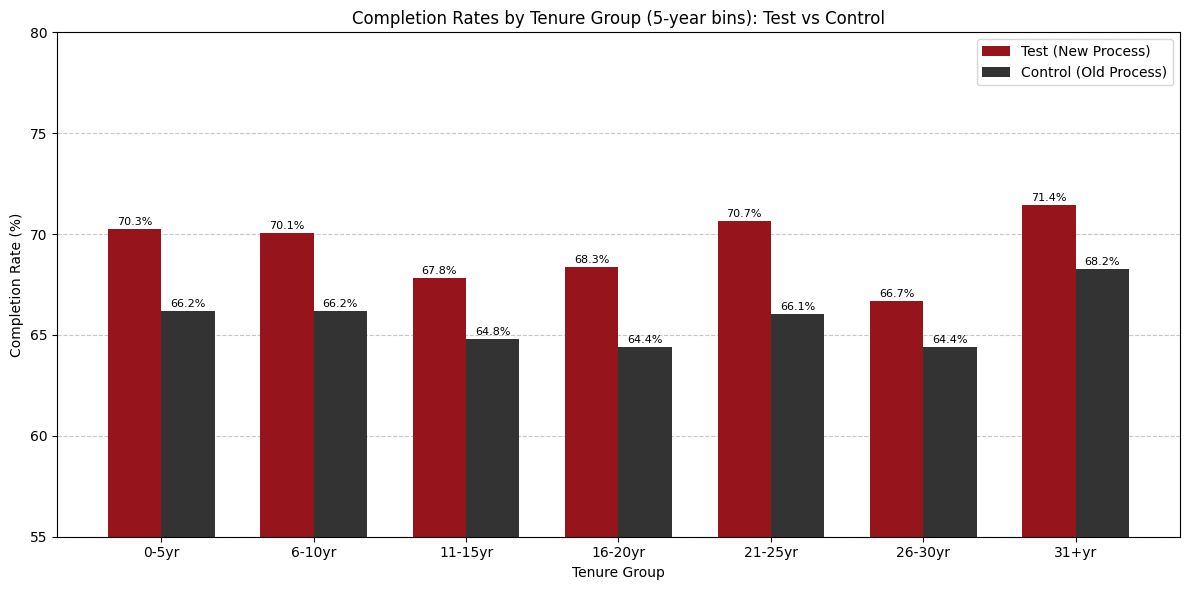

Saved: completion_by_tenure_5yr.png


In [57]:
# Create 5-year bins
bins   = [0, 5, 10, 15, 20, 25, 30, 100]
labels = ['0-5yr', '6-10yr', '11-15yr', '16-20yr', '21-25yr', '26-30yr', '31+yr']

tenure_test['tenure_group']    = pd.cut(tenure_test['clnt_tenure_yr'],    bins=bins, labels=labels)
tenure_control['tenure_group'] = pd.cut(tenure_control['clnt_tenure_yr'], bins=bins, labels=labels)

# Recalculate rates
test_rates    = tenure_test.groupby('tenure_group')['completed'].mean() * 100
control_rates = tenure_control.groupby('tenure_group')['completed'].mean() * 100

print("TEST completion rates:")
print(test_rates)
print("\nCONTROL completion rates:")
print(control_rates)

# Plot
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars_test    = ax.bar(x - width/2, test_rates,    width, label='Test (New Process)',     color='#96151d')
bars_control = ax.bar(x + width/2, control_rates, width, label='Control (Old Process)', color='#333333')

# Value labels
for bar in bars_test.patches + bars_control.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=8
    )

ax.set_xlabel('Tenure Group')
ax.set_ylabel('Completion Rate (%)')
ax.set_title('Completion Rates by Tenure Group (5-year bins): Test vs Control')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(55, 80)
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
#plt.savefig('../Figures/completion_by_tenure_5yr.png', dpi=150)
plt.show()
print("Saved: completion_by_tenure_5yr.png")

Calculating the drop off in percentages of the people who reached that step:

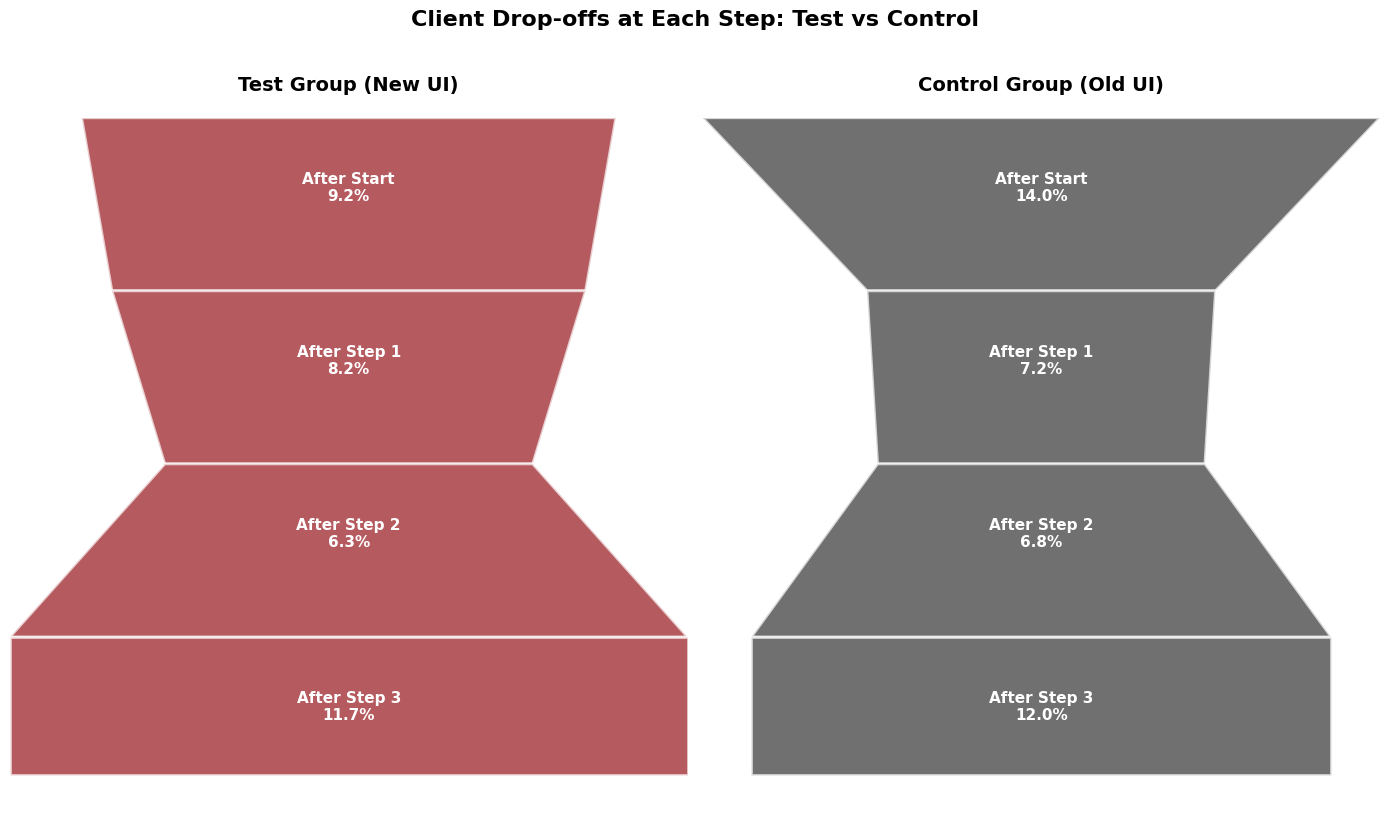

In [58]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

steps_labels = ['After Start', 'After Step 1', 'After Step 2', 'After Step 3']

# Abandoned / clients who reached that step
test_dropoff = [2454/26672*100, 1979/24260*100, 1410/22252*100, 2436/20876*100]
control_dropoff = [3285/23392*100, 1455/20147*100, 1265/18645*100, 2093/17417*100]

def draw_reverse_funnel(ax, data, labels, color, title):
    max_width = 0.8
    for i, (pct, label) in enumerate(zip(data, labels)):
        width = max_width * pct / max(data)
        left = (max_width - width) / 2
        
        if i < len(data) - 1:
            next_width = max_width * data[i+1] / max(data)
            next_left = (max_width - next_width) / 2
            coords = [[left, -i], [left+width, -i],
                      [next_left+next_width, -i-1], [next_left, -i-1]]
        else:
            coords = [[left, -i], [left+width, -i],
                      [left+width, -i-0.8], [left, -i-0.8]]
        
        polygon = plt.Polygon(coords, closed=True,
                             facecolor=color, alpha=0.7,
                             edgecolor='white', linewidth=2)
        ax.add_patch(polygon)
        
        ax.text(0.4, -i-0.4, f'{label}\n{pct:.1f}%',
                ha='center', va='center',
                fontsize=11, fontweight='bold', color='white')
    
    ax.set_xlim(0, max_width)
    ax.set_ylim(-len(data), 0)
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)

draw_reverse_funnel(ax1, test_dropoff, steps_labels, '#96151D', 'Test Group (New UI)')
draw_reverse_funnel(ax2, control_dropoff, steps_labels, '#333333', 'Control Group (Old UI)')

plt.suptitle('Client Drop-offs at Each Step: Test vs Control',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../Figures/drop_off_per_steo.png",dpi=300)
plt.show()

In [ ]:
#getting csv file for Tableau
"""
rows = []
for label, test_pct, control_pct in zip(steps_labels, test_dropoff, control_dropoff):
    rows.append({'step': label, 'group': 'test',    'dropoff_pct': round(test_pct, 2)})
    rows.append({'step': label, 'group': 'control', 'dropoff_pct': round(control_pct, 2)})

df_dropoff = pd.DataFrame(rows)
df_dropoff.to_csv('funnel_dropoff.csv', index=False)

print(df_dropoff)
"""

"\nrows = []\nfor label, test_pct, control_pct in zip(steps_labels, test_dropoff, control_dropoff):\n    rows.append({'step': label, 'group': 'test',    'dropoff_pct': round(test_pct, 2)})\n    rows.append({'step': label, 'group': 'control', 'dropoff_pct': round(control_pct, 2)})\n\ndf_dropoff = pd.DataFrame(rows)\ndf_dropoff.to_csv('funnel_dropoff.csv', index=False)\n\nprint(df_dropoff)\n"

In [ ]:
#save cleaned data file
#group_df.to_csv('group_df.csv', index=False)

trying to find out all error types per client

In [59]:
steps = ['start', 'step_1', 'step_2', 'step_3', 'confirm']
step_order = {s: i for i, s in enumerate(steps)}

df_web['date_time'] = pd.to_datetime(df_web['date_time'])

def detect_errors(group):
    group = group.sort_values('date_time')
    sequence = group['process_step'].tolist()
    errors = []

    # 1. Never used start
    if 'start' not in sequence:
        errors.append('missing_start')

    # 2. Never reached confirm
    if 'confirm' not in sequence:
        errors.append('missing_confirm')

    # 3. Skipped a step (e.g. went from start straight to step_2)
    visited = [s for s in steps if s in sequence]
    for i in range(len(visited) - 1):
        expected_next = steps[steps.index(visited[i]) + 1] if steps.index(visited[i]) + 1 < len(steps) else None
        if expected_next and visited[i+1] != expected_next:
            errors.append(f'skipped_step')

    # 4. Went backwards (e.g. step_3 -> step_2)
    for i in range(len(sequence) - 1):
        curr = sequence[i]
        nxt = sequence[i+1]
        if curr in step_order and nxt in step_order:
            if step_order[nxt] < step_order[curr]:
                errors.append(f'went_back:{curr}_to_{nxt}')

    # 5. Repeated a step more than once
    for step in steps:
        count = sequence.count(step)
        if count > 1:
            errors.append(f'repeated:{step}')

    return errors

# Apply to all clients
error_records = []
for client_id, group in df_web.groupby('client_id'):
    errors = detect_errors(group)
    for e in errors:
        error_records.append({'client_id': client_id, 'error': e})

error_df = pd.DataFrame(error_records)

# Summary
print(error_df['error'].value_counts())
print(f"\nTotal clients with at least one error: {error_df['client_id'].nunique()}")
print(f"Total clients: {df_web['client_id'].nunique()}")

error
repeated:start                 54553
missing_confirm                39012
repeated:step_1                34514
went_back:step_1_to_start      28252
repeated:step_2                21749
repeated:step_3                13908
repeated:confirm               12406
went_back:step_2_to_step_1     12294
went_back:step_3_to_start      11070
went_back:step_3_to_step_2      9465
went_back:step_2_to_start       8008
went_back:confirm_to_start      3442
went_back:step_3_to_step_1      1699
missing_start                   1177
went_back:confirm_to_step_1      562
skipped_step                     410
went_back:confirm_to_step_3      255
went_back:confirm_to_step_2        9
Name: count, dtype: int64

Total clients with at least one error: 82978
Total clients: 120157


In [ ]:
#save cleaned data file
#error_df.to_csv('error_df.csv', index=False)

Splitting the errors in test and control group

In [ ]:
test_clients = set(tenure_test['client_id'])
control_clients = set(tenure_control['client_id'])

error_records = []
for client_id, group in df_web.groupby('client_id'):
    if client_id in test_clients:
        grp = 'test'
    elif client_id in control_clients:
        grp = 'control'
    else:
        continue  # skip clients not in either group

    errors = detect_errors(group)
    for e in errors:
        error_records.append({'client_id': client_id, 'group': grp, 'error': e})

error_df = pd.DataFrame(error_records)

for grp in ['test', 'control']:
    print(f"\n{'='*30}")
    print(f"{grp.upper()} GROUP:")
    print(f"{'='*30}")
    print(error_df[error_df['group'] == grp]['error'].value_counts())


TEST GROUP:
error
repeated:start                 12367
repeated:step_1                 8433
missing_confirm                 8279
went_back:step_1_to_start       7614
repeated:step_2                 5036
repeated:confirm                3824
went_back:step_2_to_step_1      3173
repeated:step_3                 3161
went_back:step_3_to_start       2881
went_back:step_3_to_step_2      2300
went_back:step_2_to_start       2136
went_back:confirm_to_start       663
missing_start                    289
went_back:step_3_to_step_1       236
skipped_step                      81
went_back:confirm_to_step_1       48
went_back:confirm_to_step_3       29
went_back:confirm_to_step_2        2
Name: count, dtype: int64

CONTROL GROUP:
error
repeated:start                 10110
missing_confirm                 8098
repeated:step_1                 5794
repeated:step_2                 4660
went_back:step_1_to_start       3558
repeated:step_3                 3546
went_back:step_3_to_step_2      2371
went_bac

In [ ]:
n_test = 26961
n_control = 23527

labels = [
    'repeated: start',
    'repeated: step 1',
    'missing confirm',
    'went back: step 1 → start',
    'repeated: step 2',
    'repeated: confirm',
    'went back: step 2 → step 1',
    'repeated: step 3',
    'went back: step 3 → start',
    'went back: step 3 → step 2',
    'went back: step 2 → start',
    'went back: confirm → start',
    'missing start',
    'went back: step 3 → step 1',
    'skipped step',
    'went back: confirm → step 1',
    'went back: confirm → step 3',
    'went back: confirm → step 2'
]

test_raw    = [12367, 8433, 8279, 7614, 5036, 3824, 3173, 3161, 2881, 2300, 2136, 663, 289, 236, 81, 48, 29, 2]
control_raw = [10110, 5794, 8098, 3558, 4660, 1091, 1409, 3546, 1902, 2371, 1344, 1680, 135, 835, 123, 101, 130, 0]

test_pct    = [v / n_test * 100 for v in test_raw]
control_pct = [v / n_control * 100 for v in control_raw]

x = np.arange(len(labels))
bar_height = 0.35

fig, ax = plt.subplots(figsize=(14, 14))

bars_test    = ax.barh(x + bar_height/2, test_pct,    bar_height, label=f'Test (new UI, n={n_test:,})',    color='#96151D')
bars_control = ax.barh(x - bar_height/2, control_pct, bar_height, label=f'Control (old UI, n={n_control:,})', color='#333333')

# Add percentage labels to bars
for bar in bars_test:
    width = bar.get_width()
    if width > 0:
        ax.text(width + 0.1, bar.get_y() + bar.get_height()/2,
                f'{width:.1f}%', va='center', ha='left', fontsize=9, color='black')

for bar in bars_control:
    width = bar.get_width()
    if width > 0:
        ax.text(width + 0.1, bar.get_y() + bar.get_height()/2,
                f'{width:.1f}%', va='center', ha='left', fontsize=9, color='black')

ax.set_yticks(x)
ax.set_yticklabels(labels, fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}%'))
ax.set_xlabel('% of total clients in group')
ax.legend(fontsize=11)
ax.set_title('Error distribution: test vs control (% of group)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add a bit of x margin so labels don't get cut off
ax.set_xlim(0, max(max(test_pct), max(control_pct)) + 5)

plt.tight_layout()
plt.show()


KeyboardInterrupt



In [ ]:
""" for Tableau
rows = []
for label, t_raw, t_pct, c_raw, c_pct in zip(labels, test_raw, test_pct, control_raw, control_pct):
    rows.append({'error_type': label, 'group': 'test',    'count': t_raw, 'pct_of_group': round(t_pct, 2)})
    rows.append({'error_type': label, 'group': 'control', 'count': c_raw, 'pct_of_group': round(c_pct, 2)})

df_errors = pd.DataFrame(rows)
df_errors.to_csv('error_distribution.csv', index=False)

print(df_errors)"""

                     error_type    group  count  pct_of_group
0               repeated: start     test  12367         45.87
1               repeated: start  control  10110         42.97
2              repeated: step 1     test   8433         31.28
3              repeated: step 1  control   5794         24.63
4               missing confirm     test   8279         30.71
5               missing confirm  control   8098         34.42
6     went back: step 1 → start     test   7614         28.24
7     went back: step 1 → start  control   3558         15.12
8              repeated: step 2     test   5036         18.68
9              repeated: step 2  control   4660         19.81
10            repeated: confirm     test   3824         14.18
11            repeated: confirm  control   1091          4.64
12   went back: step 2 → step 1     test   3173         11.77
13   went back: step 2 → step 1  control   1409          5.99
14             repeated: step 3     test   3161         11.72
15      

checking if the people that went from confirmed to start belong to the errors or that they started a new process

In [ ]:
# Find clients who went confirm -> start
confirm_to_start_clients = error_df[error_df['error'] == 'went_back:confirm_to_start']['client_id'].values

# Look at their full journeys with timestamps
sample = confirm_to_start_clients[:5]

for client in sample:
    print(f"\nClient {client}:")
    print(df_web[df_web['client_id'] == client][['process_step', 'date_time']].sort_values('date_time').to_string(index=False))


Client 1836:
process_step           date_time
       start 2017-04-05 18:47:54
      step_1 2017-04-05 18:48:00
      step_2 2017-04-05 18:48:27
      step_3 2017-04-05 18:48:54
     confirm 2017-04-05 18:49:51
     confirm 2017-04-05 18:53:03
       start 2017-04-06 07:13:35
      step_1 2017-04-06 07:14:34
       start 2017-04-07 09:33:50
      step_1 2017-04-07 09:33:54
       start 2017-04-07 09:36:07
      step_1 2017-04-07 09:36:21

Client 5354:
process_step           date_time
       start 2017-04-12 20:30:01
      step_1 2017-04-12 20:30:14
      step_2 2017-04-12 20:30:22
      step_3 2017-04-12 20:30:39
     confirm 2017-04-12 20:31:31
       start 2017-04-13 20:22:33
      step_1 2017-04-13 20:22:39

Client 16135:
process_step           date_time
       start 2017-04-09 20:20:30
       start 2017-04-10 19:23:36
       start 2017-04-10 19:27:43
      step_1 2017-04-10 19:27:49
       start 2017-04-11 13:30:30
      step_1 2017-04-11 13:30:49
       start 2017-04-11 13:40:08


it looks like the clients going back from confirm to start is not an error but the start of a new process.
lets check if that might be the case for "went back" errors/ 

In [ ]:
# Calculate time between each step transition per client
went_back_errors = [e for e in error_df['error'].unique() if e.startswith('went_back')]

for error_type in sorted(went_back_errors):
    # Get clients with this error
    clients = error_df[error_df['error'] == error_type]['client_id'].values
    
    # Extract the two steps from the error name e.g. went_back:confirm_to_start
    parts = error_type.replace('went_back:', '').split('_to_')
    from_step = parts[0]
    to_step = parts[1]
    
    gaps = []
    for client in clients:
        journey = df_web[df_web['client_id'] == client].sort_values('date_time')
        journey['date_time'] = pd.to_datetime(journey['date_time'])
        steps = journey['process_step'].tolist()
        times = journey['date_time'].tolist()
        
        for i in range(len(steps) - 1):
            if steps[i] == from_step and steps[i+1] == to_step:
                gap_minutes = (times[i+1] - times[i]).total_seconds() / 60
                gaps.append(gap_minutes)
    
    if gaps:
        median_gap = np.median(gaps)
        mean_gap = np.mean(gaps)
        under_5min = sum(g < 5 for g in gaps) / len(gaps) * 100
        print(f"\n{error_type}")
        print(f"  median gap: {median_gap:.1f} min | mean gap: {mean_gap:.1f} min | under 5 min: {under_5min:.1f}%")


went_back:confirm_to_start
  median gap: 2093.0 min | mean gap: 5492.8 min | under 5 min: 25.0%

went_back:confirm_to_step_1
  median gap: 0.7 min | mean gap: 225.3 min | under 5 min: 92.8%

went_back:confirm_to_step_2
  median gap: 1.4 min | mean gap: 1.4 min | under 5 min: 100.0%

went_back:confirm_to_step_3
  median gap: 0.0 min | mean gap: 0.3 min | under 5 min: 97.5%

went_back:step_1_to_start
  median gap: 1.7 min | mean gap: 3948.2 min | under 5 min: 68.4%

went_back:step_2_to_start
  median gap: 2.3 min | mean gap: 7013.8 min | under 5 min: 61.7%

went_back:step_2_to_step_1
  median gap: 0.1 min | mean gap: 36.0 min | under 5 min: 96.6%

went_back:step_3_to_start
  median gap: 4.4 min | mean gap: 6789.9 min | under 5 min: 51.5%

went_back:step_3_to_step_1
  median gap: 1.0 min | mean gap: 537.1 min | under 5 min: 90.3%

went_back:step_3_to_step_2
  median gap: 0.6 min | mean gap: 1.4 min | under 5 min: 93.9%


In [ ]:
"""save DF for Tableau
rows = []
for d in data:
    rows.append({
        'transition':       d['label'],
        'median_gap_min':   d['median'],
        'pct_under_5_min':  d['under5'],
        'session_type':     'mostly same session' if d['under5'] >= 80 else ('mixed' if d['under5'] >= 50 else 'mostly new session')
    })

df_transitions = pd.DataFrame(rows)
df_transitions.to_csv('went_back_time_gaps.csv', index=False)

print(df_transitions)"""

         transition  median_gap_min  pct_under_5_min         session_type
0   confirm → start          2093.0             25.0   mostly new session
1  confirm → step 1             0.7             92.8  mostly same session
2  confirm → step 2             1.4            100.0  mostly same session
3  confirm → step 3             0.0             97.5  mostly same session
4    step 1 → start             1.7             68.4                mixed
5    step 2 → start             2.3             61.7                mixed
6   step 2 → step 1             0.1             96.6  mostly same session
7    step 3 → start             4.4             51.5                mixed
8   step 3 → step 1             1.0             90.3  mostly same session
9   step 3 → step 2             0.6             93.9  mostly same session


In [ ]:
data = [
    {'label': 'confirm → start',  'median': 2093.0, 'under5': 25.0},
    {'label': 'confirm → step 1', 'median': 0.7,    'under5': 92.8},
    {'label': 'confirm → step 2', 'median': 1.4,    'under5': 100.0},
    {'label': 'confirm → step 3', 'median': 0.0,    'under5': 97.5},
    {'label': 'step 1 → start',   'median': 1.7,    'under5': 68.4},
    {'label': 'step 2 → start',   'median': 2.3,    'under5': 61.7},
    {'label': 'step 2 → step 1',  'median': 0.1,    'under5': 96.6},
    {'label': 'step 3 → start',   'median': 4.4,    'under5': 51.5},
    {'label': 'step 3 → step 1',  'median': 1.0,    'under5': 90.3},
    {'label': 'step 3 → step 2',  'median': 0.6,    'under5': 93.9},
]

def get_from_step(label):
    if label.startswith('confirm'):
        return 'from confirm'
    elif label.startswith('step 3'):
        return 'from step 3'
    elif label.startswith('step 2'):
        return 'from step 2'
    elif label.startswith('step 1'):
        return 'from step 1'

rows = []
for d in data:
    rows.append({
        'transition':      d['label'],
        'median_gap_min':  d['median'],
        'pct_under_5_min': d['under5'],
        'from_step':       get_from_step(d['label'])
    })

df_transitions = pd.DataFrame(rows)
df_transitions.to_csv('went_back_time_gaps.csv', index=False)

print(df_transitions)

         transition  median_gap_min  pct_under_5_min     from_step
0   confirm → start          2093.0             25.0  from confirm
1  confirm → step 1             0.7             92.8  from confirm
2  confirm → step 2             1.4            100.0  from confirm
3  confirm → step 3             0.0             97.5  from confirm
4    step 1 → start             1.7             68.4   from step 1
5    step 2 → start             2.3             61.7   from step 2
6   step 2 → step 1             0.1             96.6   from step 2
7    step 3 → start             4.4             51.5   from step 3
8   step 3 → step 1             1.0             90.3   from step 3
9   step 3 → step 2             0.6             93.9   from step 3
